In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
import sys
project_root = Path.cwd() / "../../"
sys.path.append(str(project_root))

from utils.visualizations import (
    within_metric_barplot, within_metric_dotplot,
    multi_within_metric_barplot, multi_within_metric_dotplot,
    across_metric_barplot, across_metric_dotplot,
    few_shot_dev, multi_few_shot_dev
)

# **Data Loading**

In [2]:
# import all json files
with open("cross_val_results/evaluation_metrics_bert_ner.json", "r") as f:
    bert_results = json.load(f)

with open("cross_val_results/evaluation_metrics_dictionary_ner.json", "r") as f:
    dictionary_results = json.load(f)

with open("cross_val_results/evaluation_metrics_gen_llm_ner.json", "r") as f:
    gpt_results = json.load(f)

# combine all models
all_metrics = {**bert_results, **dictionary_results, **gpt_results}

# rename cross-span to cross_span
for model in all_metrics:
    if "cross-span" in all_metrics[model]:
        all_metrics[model]["cross_span"] = all_metrics[model].pop("cross-span")

# reorder the dictionaries
bert_results = dict(
    (k, bert_results[k]) for k in [
        'roberta-base',
        'microsoft/deberta-v3-base',
        'bert-base-cased',
        'distilbert-base-cased'
    ]
)    

all_results = dict(
    (k, all_metrics[k]) for k in [
        'roberta-base',
        'microsoft/deberta-v3-base',
        'bert-base-cased',
        'distilbert-base-cased',
        'dictionary',
        'gpt-5-nano',
        'gpt-4o-mini'
    ]
)

# **Model Comparisons Within Model Group**

## **Dictionary Baseline**

In [3]:
main_metrics_remap = {
        "seqeval": "Seqeval", "cross_span": "Cross-Span Averages", "mention_detection": "Mention Detection", "sentence_level": "Sentence Level"
    }

focus_metrics = ["seqeval", "cross_span", "mention_detection", "sentence_level"]

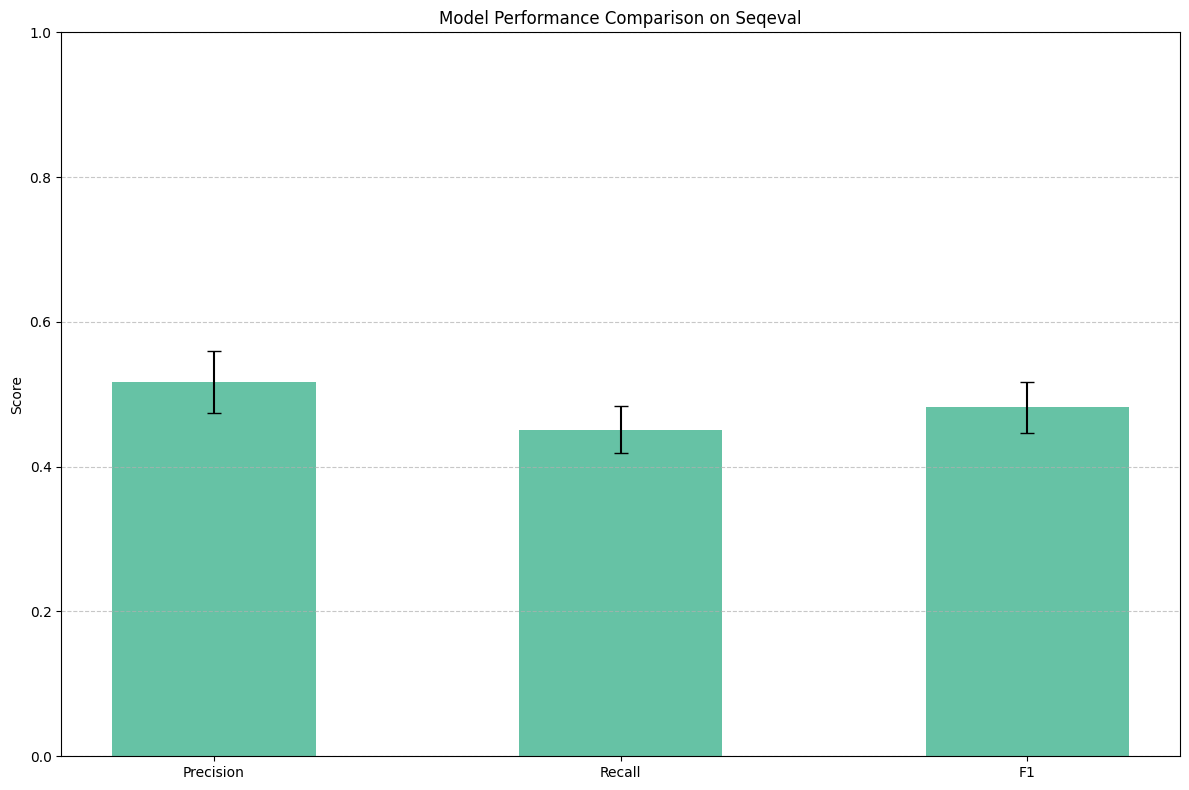

In [4]:
within_metric_barplot(eval_results=dictionary_results, focus_metrics=["seqeval"], metric_title_remap=main_metrics_remap, group_width=0.5, color_scheme=plt.cm.Set2.colors)
#within_metric_dotplot(eval_results=dictionary_results, focus_metrics=["seqeval"], metric_title_remap=main_metrics_remap, group_width=0.5, color_scheme=plt.cm.Set2.colors, marker="o")

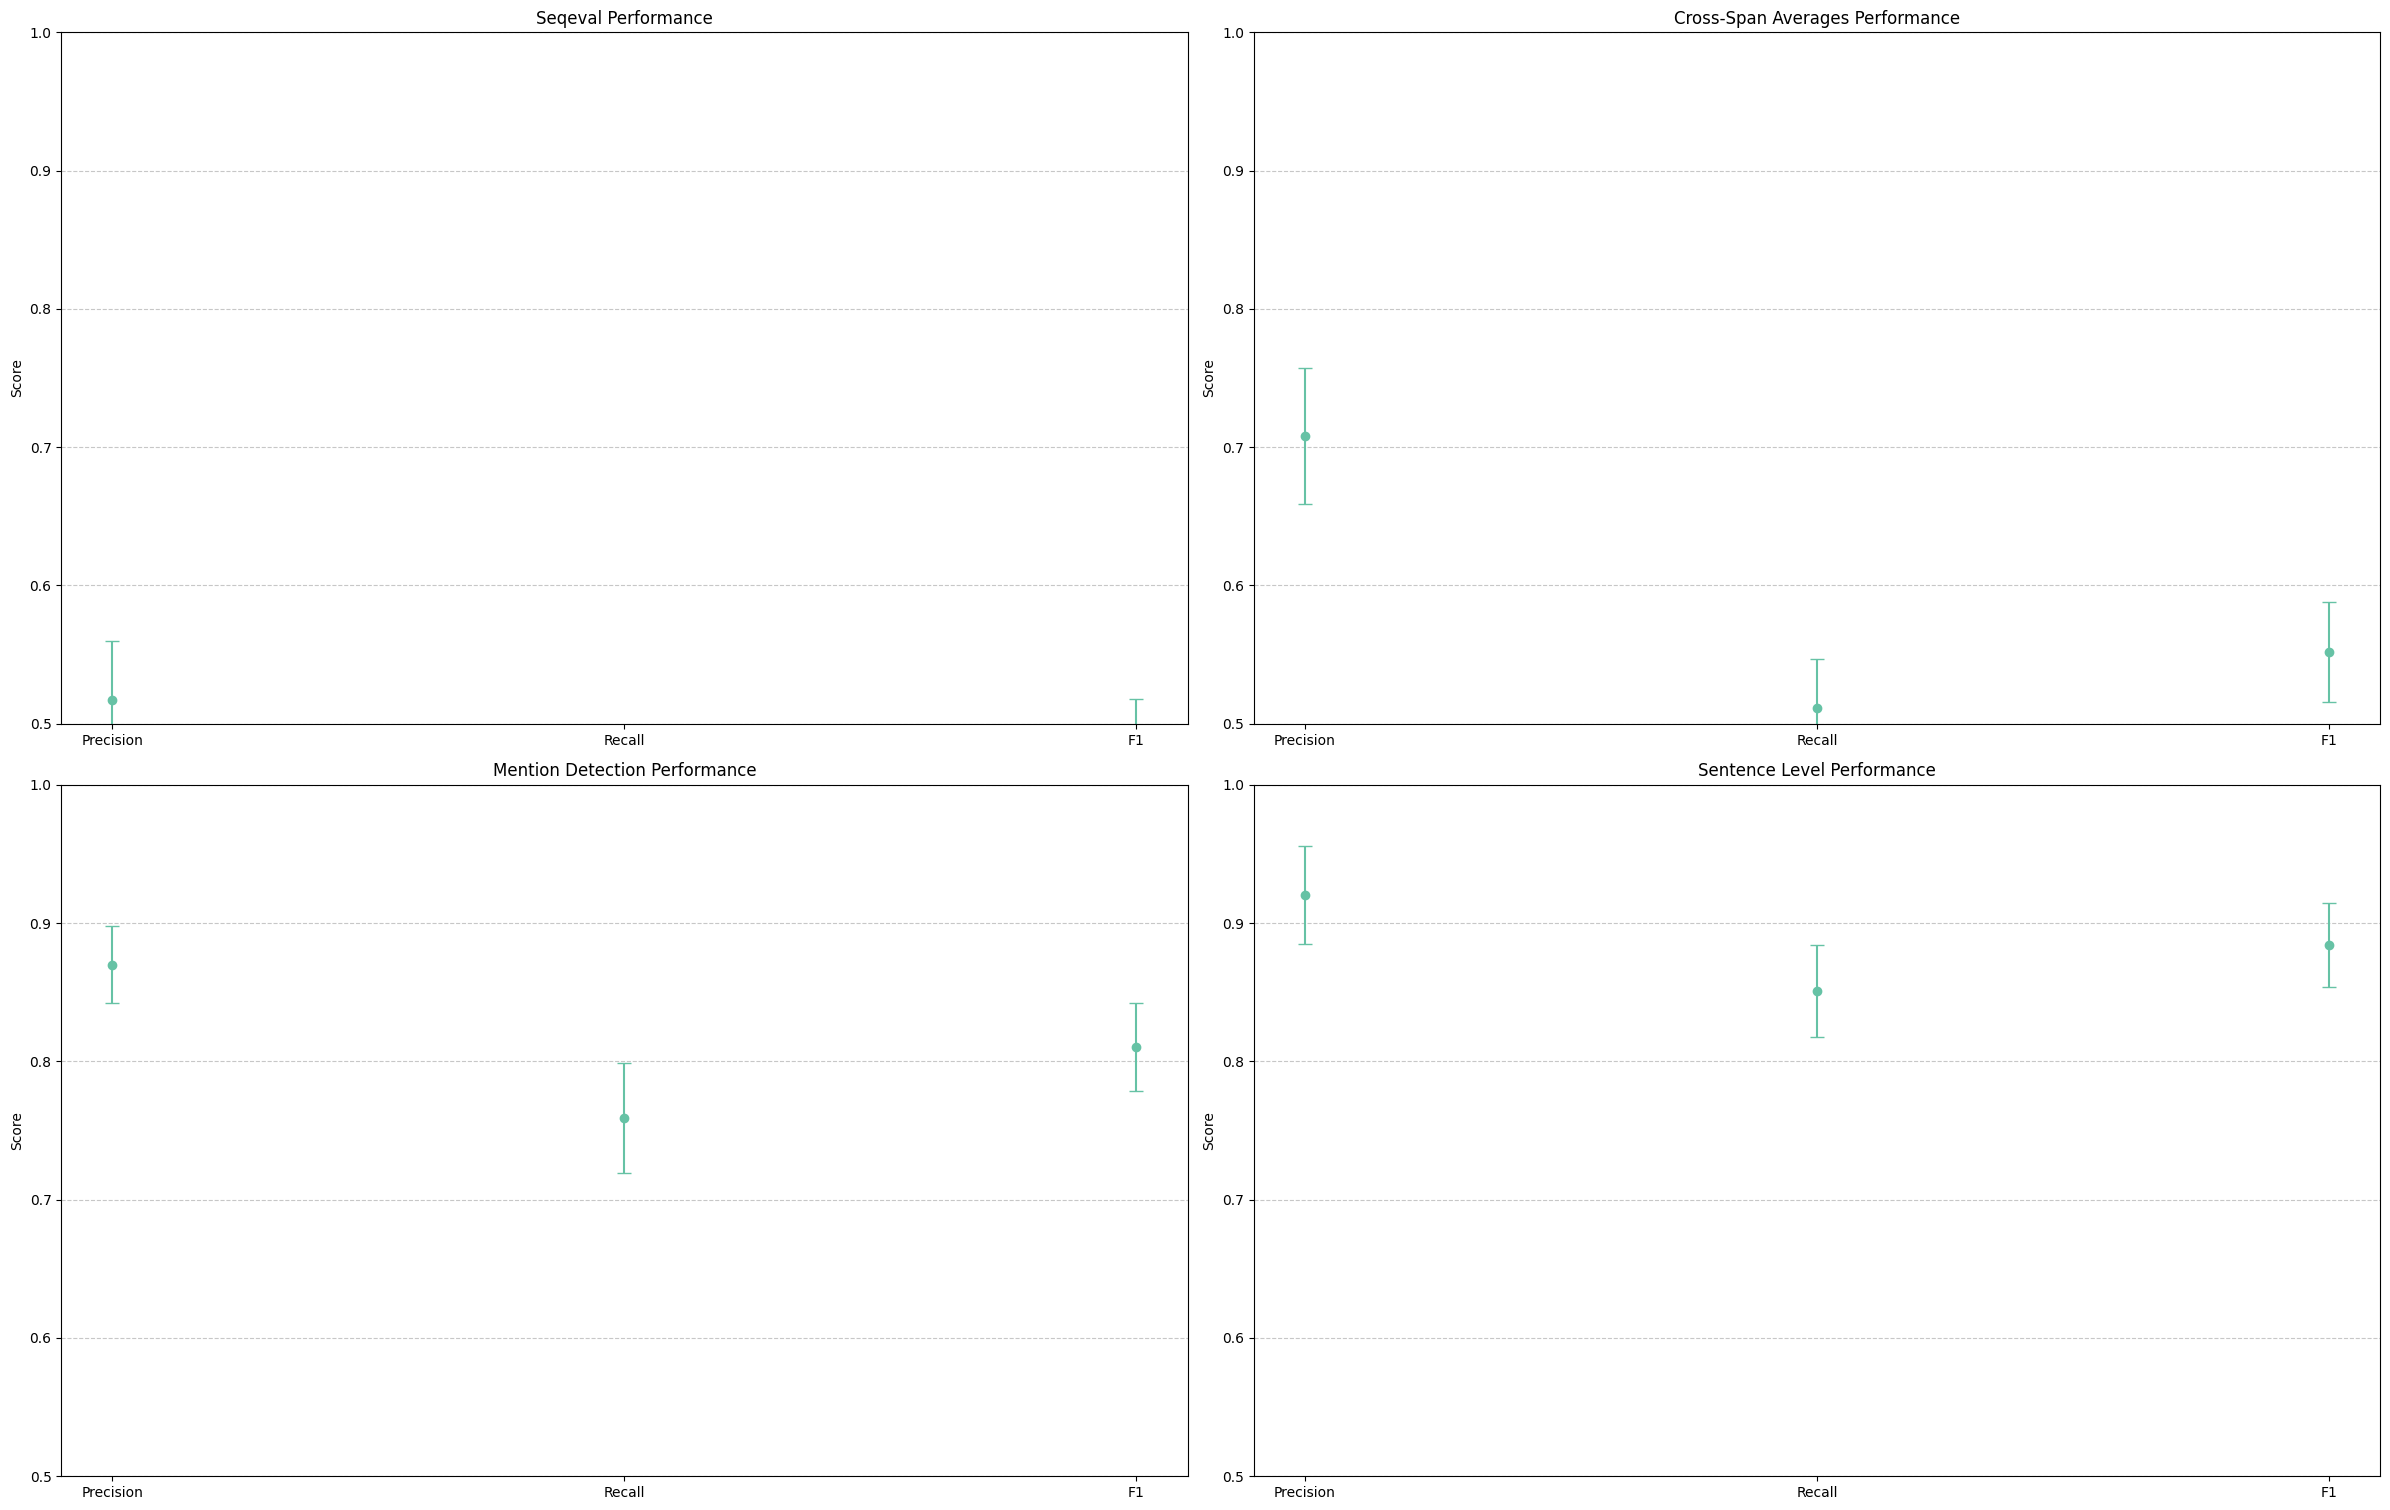

In [5]:
#multi_within_metric_barplot(dictionary_results, focus_metrics, metric_title_remap=main_metrics_remap, group_width=0.7, color_scheme=plt.cm.Set2.colors)
multi_within_metric_dotplot(dictionary_results, focus_metrics, metric_title_remap=main_metrics_remap, group_width=0.7, color_scheme=plt.cm.Set2.colors, marker="o")

## **BERT Models**

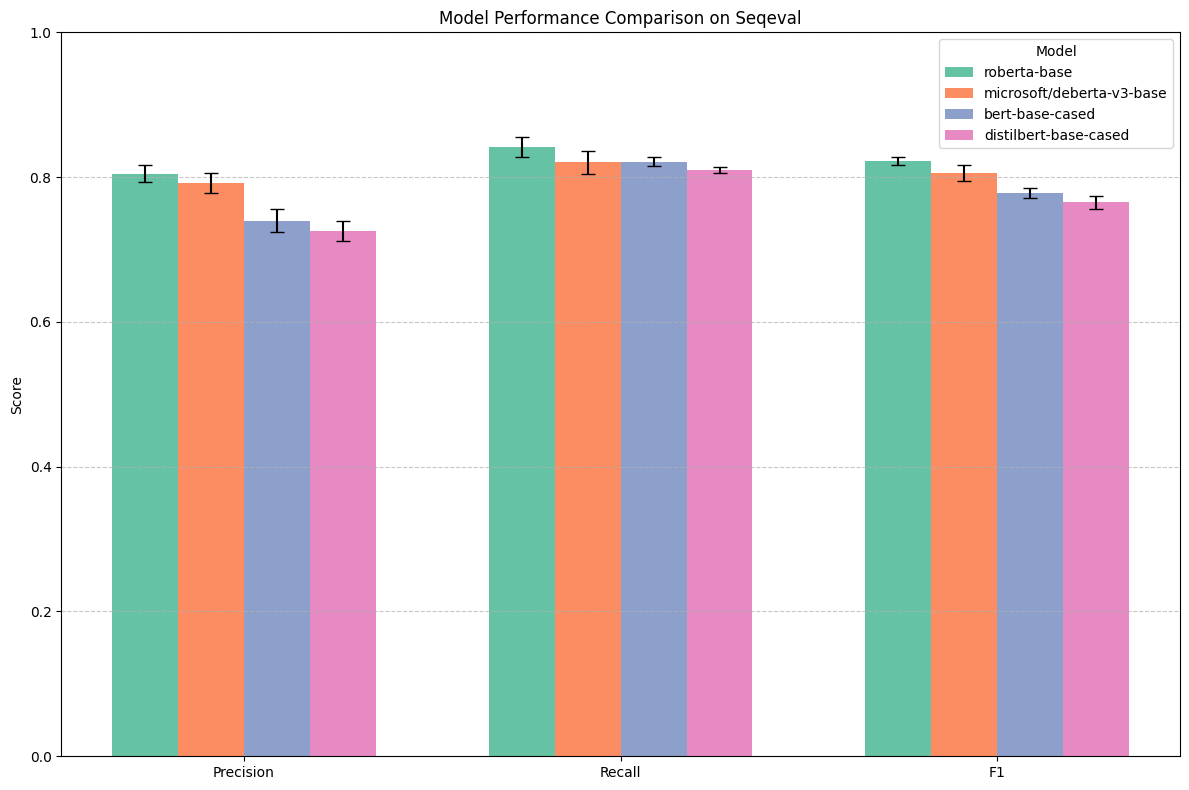

In [6]:
within_metric_barplot(eval_results=bert_results, focus_metrics=["seqeval"], metric_title_remap=main_metrics_remap, group_width=0.7, color_scheme=plt.cm.Set2.colors)
#within_metric_dotplot(eval_results=bert_results, focus_metrics=["seqeval"], metric_title_remap=main_metrics_remap, group_width=0.3, color_scheme=plt.cm.Set2.colors, marker="o")

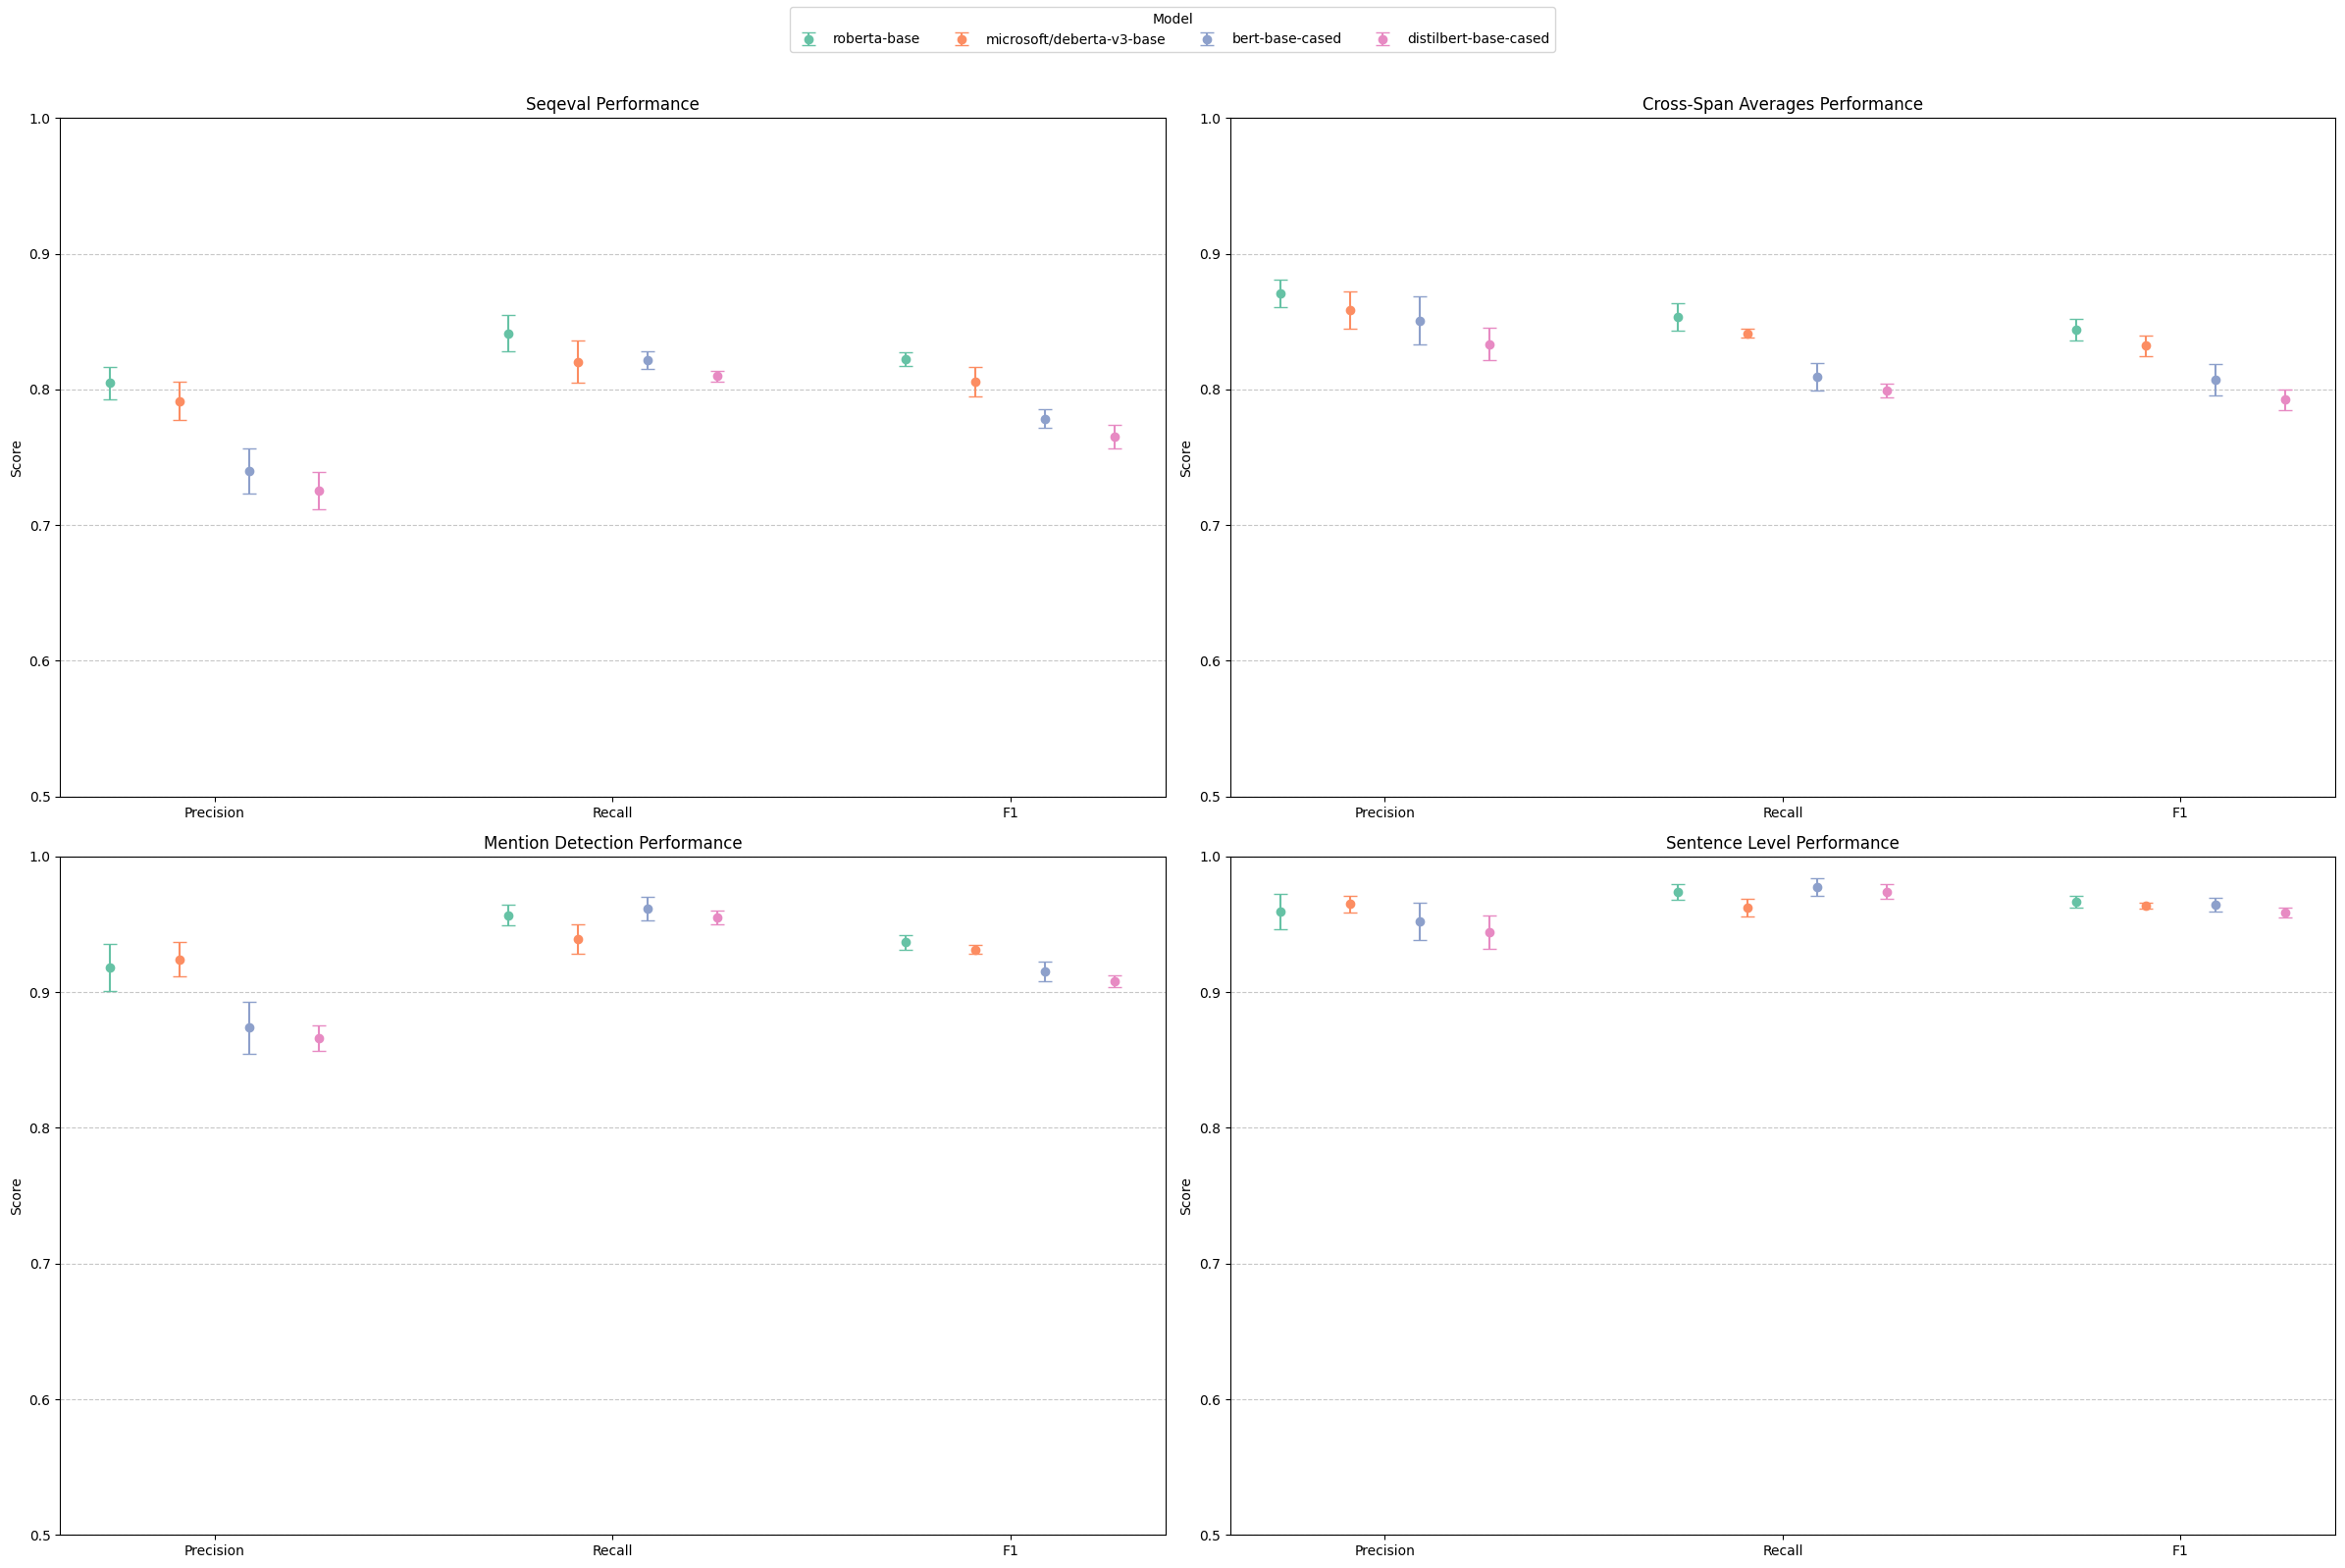

In [7]:
#multi_within_metric_barplot(bert_results, focus_metrics, metric_title_remap=main_metrics_remap, group_width=0.7, color_scheme=plt.cm.Set2.colors)
multi_within_metric_dotplot(bert_results, focus_metrics, metric_title_remap=main_metrics_remap, group_width=0.7, color_scheme=plt.cm.Set2.colors, marker="o")

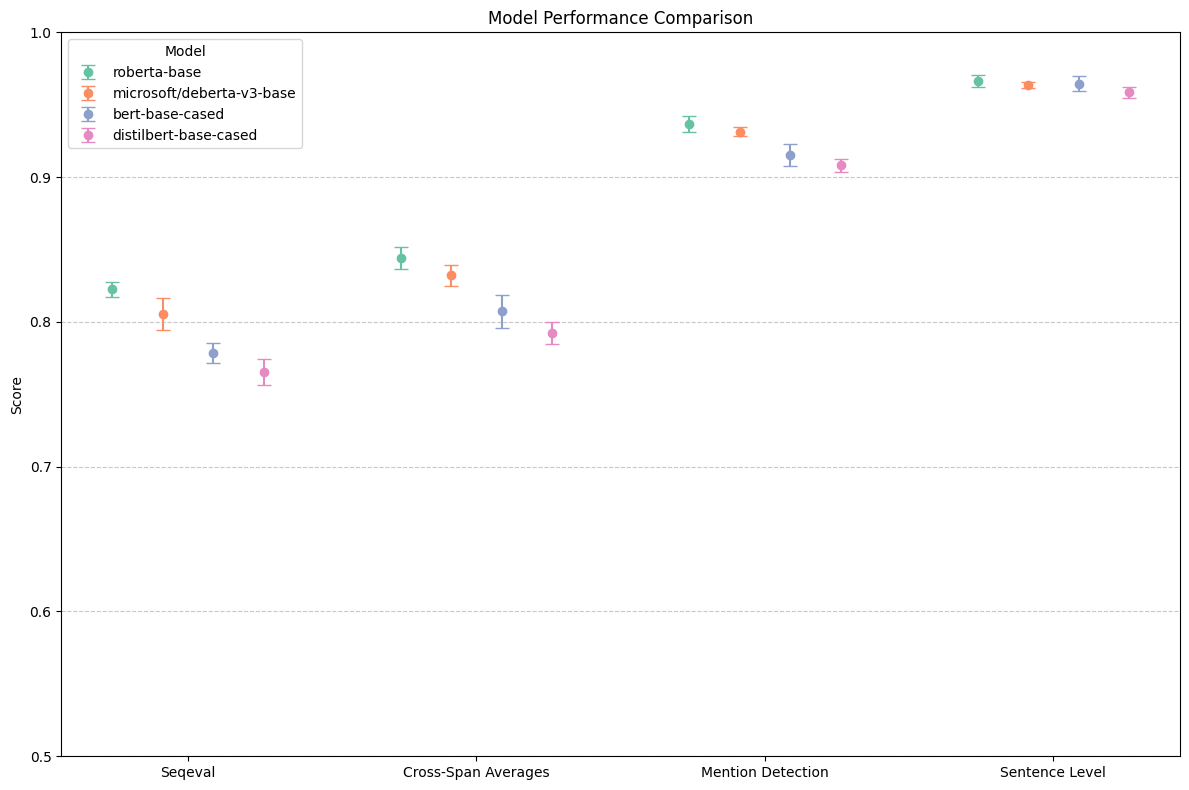

In [8]:
#across_metric_barplot(eval_results=bert_results, focus_metrics=focus_metrics, comparison_metric="f1", main_metrics_remap=main_metrics_remap, group_width=0.7, color_scheme=plt.cm.Set2.colors)
across_metric_dotplot(eval_results=bert_results, focus_metrics=focus_metrics, comparison_metric="f1", main_metrics_remap=main_metrics_remap, group_width=0.7, color_scheme=plt.cm.Set2.colors, marker="o")

## **Generative Models**

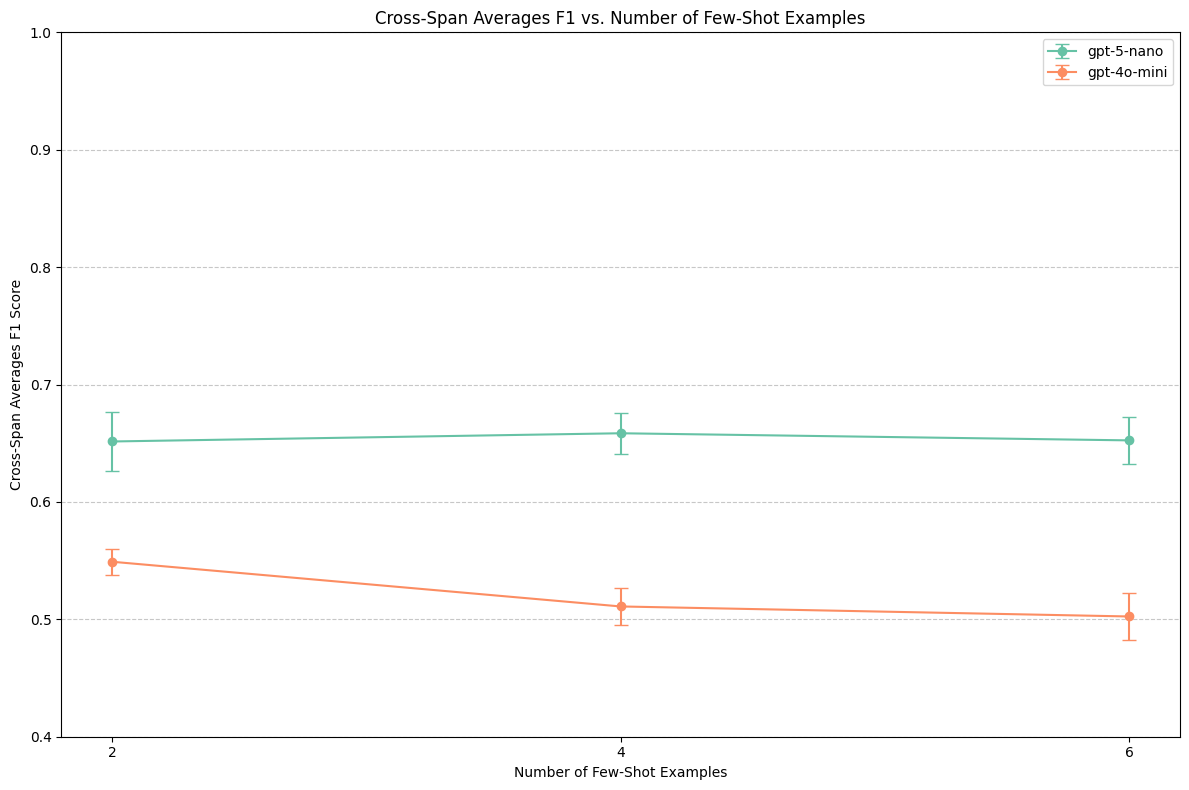

In [9]:
few_shot_dev(gpt_results, ["cross_span"], comparison_metric="f1", main_metrics_remap=main_metrics_remap)   

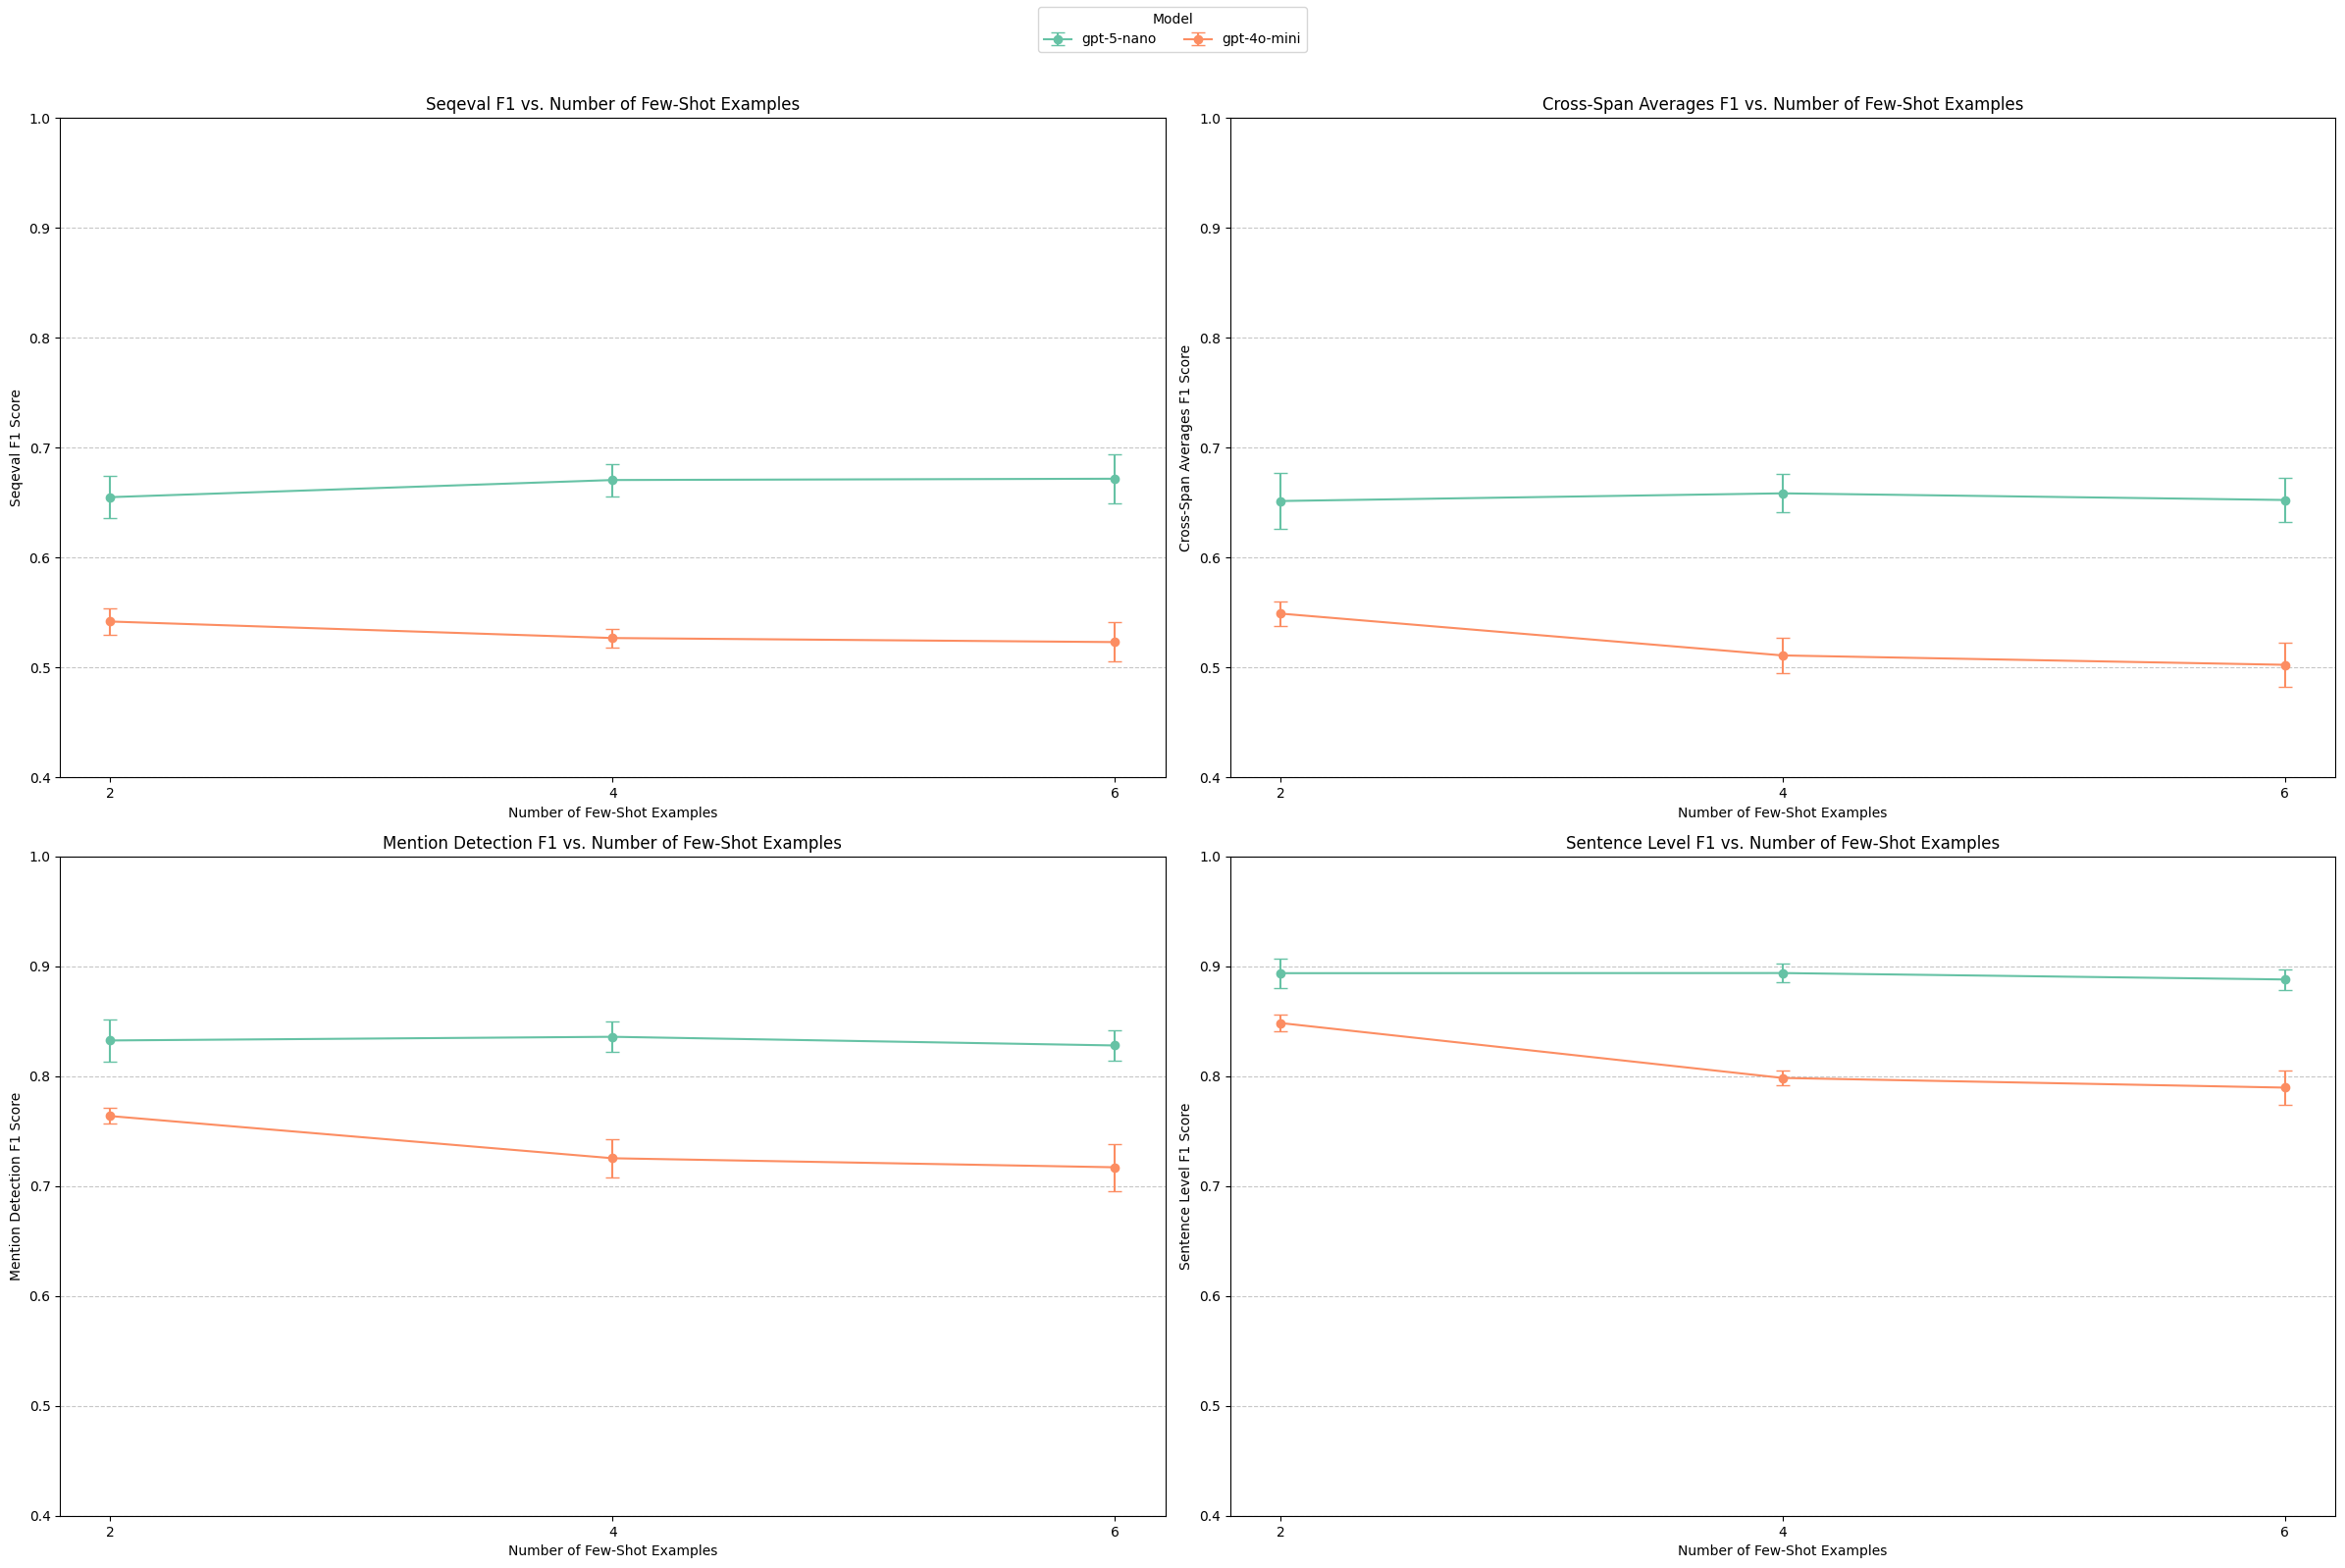

In [10]:
multi_few_shot_dev(gpt_results, focus_metrics, comparison_metric="f1", main_metrics_remap=main_metrics_remap)   

In [11]:
# store the best version of each model family
best_gen_llm = {"gpt-5-nano": {},
                "gpt-4o-mini": {}}

for method in gpt_results:
    best_seqeval = 0
    best_num_few_shot = None
    for num_few_shot in gpt_results[method]:
        seqeval_score = gpt_results[method][num_few_shot]["seqeval"]["f1"]["mean"]
        if seqeval_score > best_seqeval:
            best_num_few_shot = num_few_shot
            best_seqeval = seqeval_score
    best_gen_llm[method] = gpt_results[method][best_num_few_shot]
    print(f"Model: {method}")
    print(f"Best performance with {int(best_num_few_shot.split("_")[0])} few-shot examples")
    print(f"Best seqeval score: {best_seqeval:.4f}")
    print("-"*50)

Model: gpt-5-nano
Best performance with 6 few-shot examples
Best seqeval score: 0.6718
--------------------------------------------------
Model: gpt-4o-mini
Best performance with 2 few-shot examples
Best seqeval score: 0.5418
--------------------------------------------------


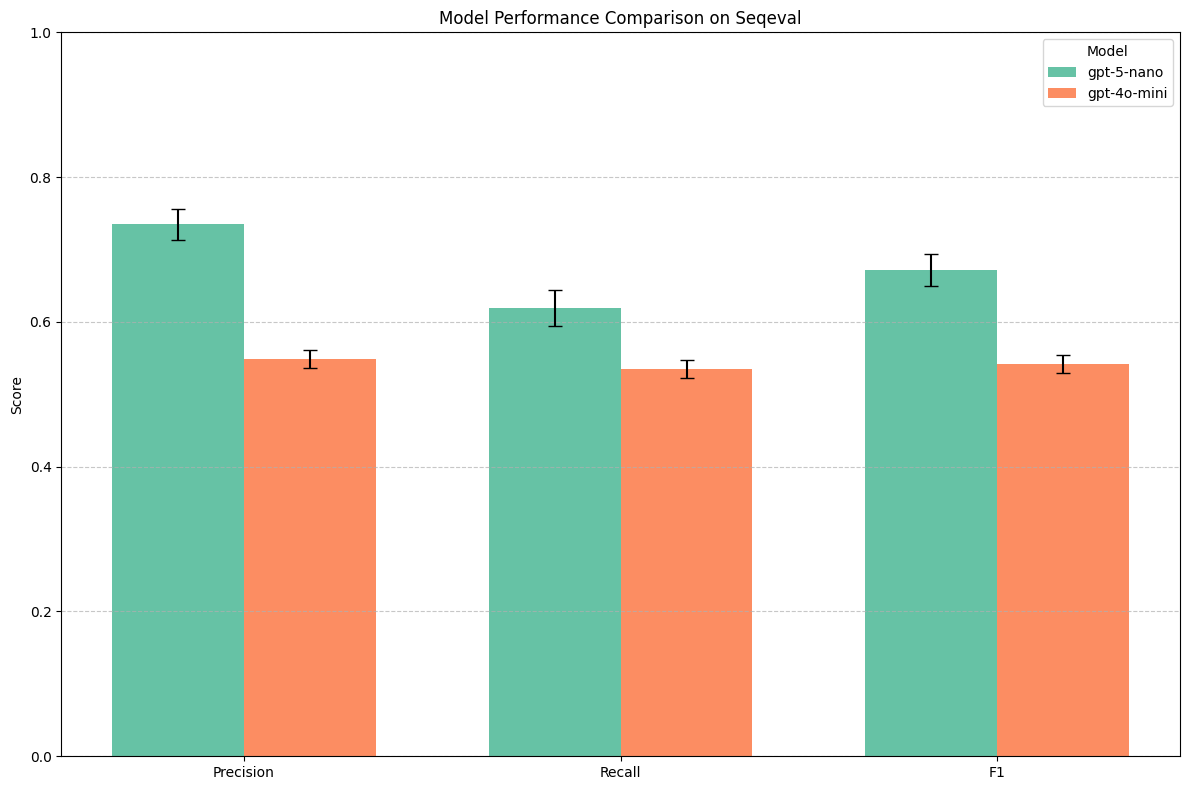

In [12]:
within_metric_barplot(eval_results=best_gen_llm, focus_metrics=["seqeval"], metric_title_remap=main_metrics_remap, group_width=0.7, color_scheme=plt.cm.Set2.colors)
#within_metric_dotplot(eval_results=best_gen_llm, focus_metrics=["seqeval"], metric_title_remap=main_metrics_remap, group_width=0.3, color_scheme=plt.cm.Set2.colors, marker="o")

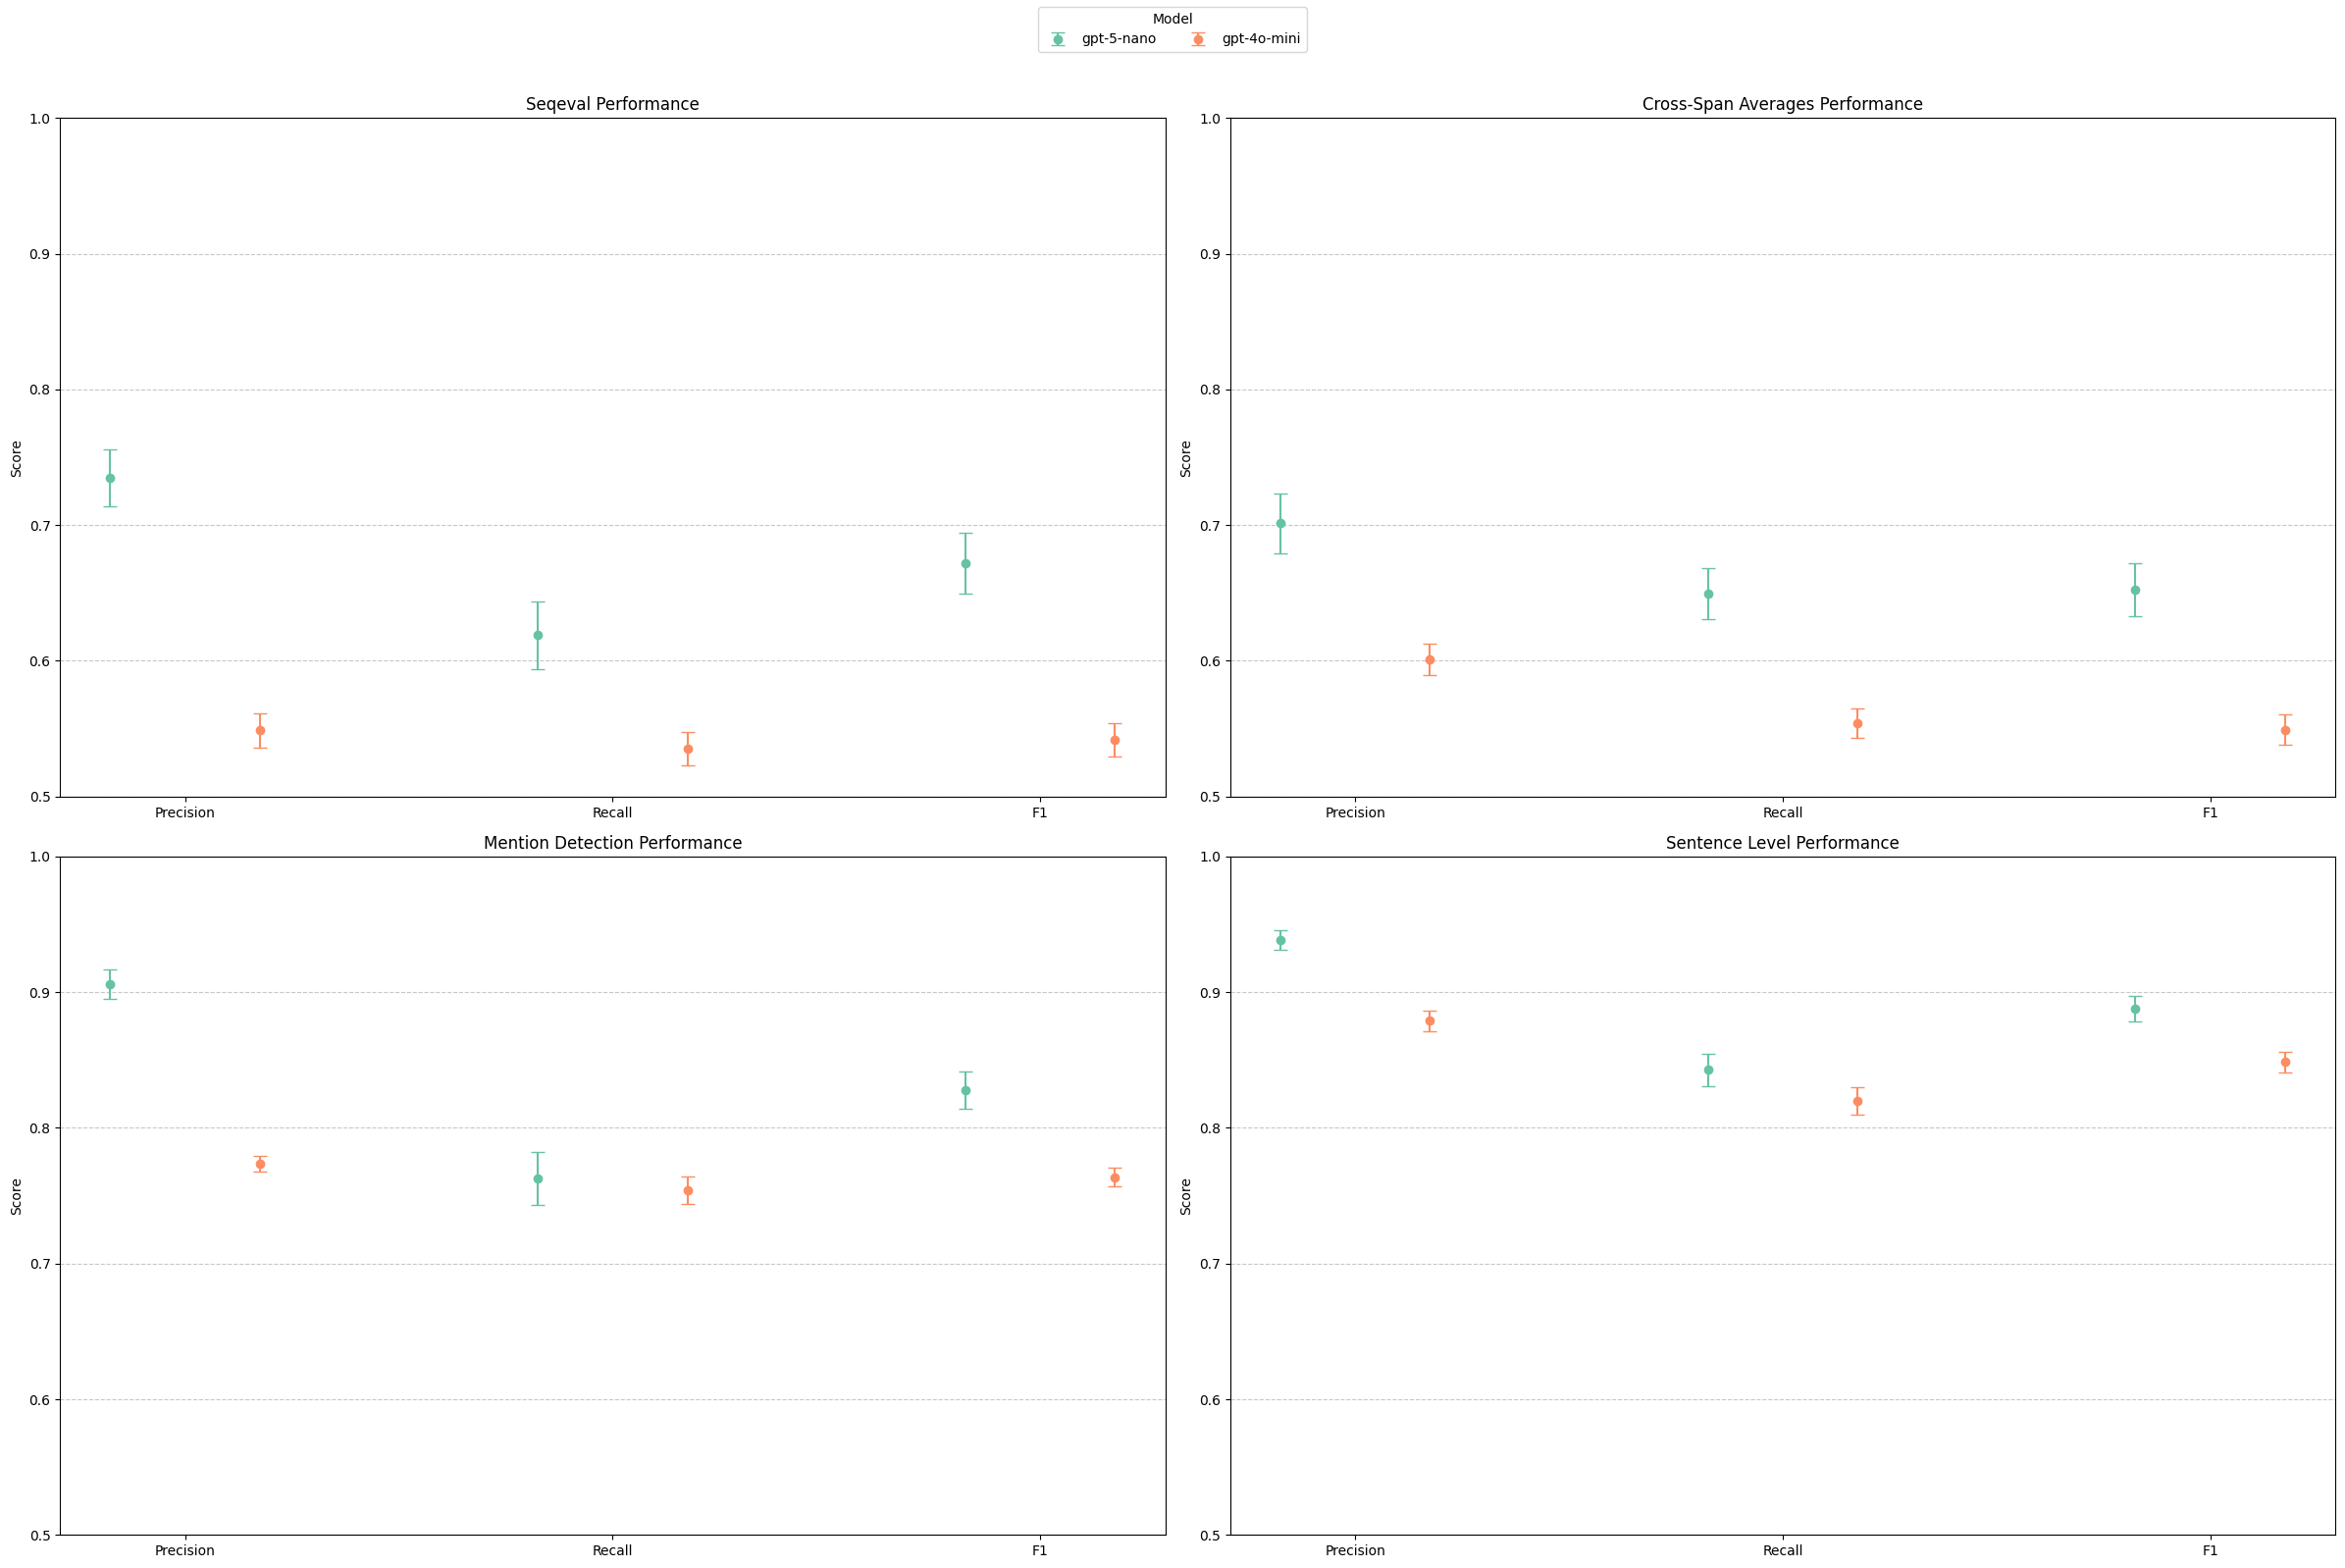

In [13]:
#multi_within_metric_barplot(best_gen_llm, focus_metrics, metric_title_remap=main_metrics_remap, group_width=0.7, color_scheme=plt.cm.Set2.colors)
multi_within_metric_dotplot(best_gen_llm, focus_metrics, metric_title_remap=main_metrics_remap, group_width=0.7, color_scheme=plt.cm.Set2.colors, marker="o")

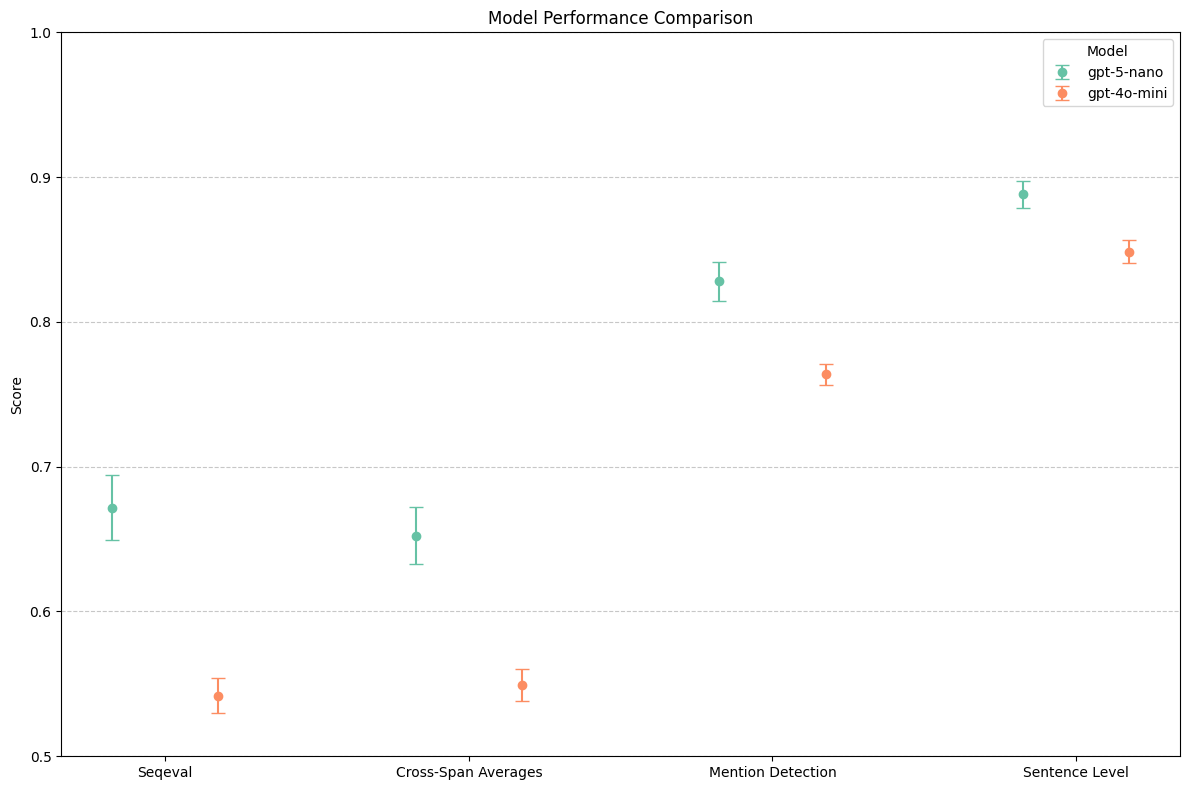

In [14]:
#across_metric_barplot(eval_results=best_gen_llm, focus_metrics=main_metrics, comparison_metric="f1", main_metrics_remap=main_metrics_remap, group_width=0.7, color_scheme=plt.cm.Set2.colors)
across_metric_dotplot(eval_results=best_gen_llm, focus_metrics=focus_metrics, comparison_metric="f1", main_metrics_remap=main_metrics_remap, group_width=0.7, color_scheme=plt.cm.Set2.colors, marker="o")

# **Model Comparison Across Model Groups**